<a href="https://colab.research.google.com/github/suhyeon523/Project3_ECON148/blob/main/notebooks/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split

#1. Data Loading, Filtering, and Reshaping of the Target Variable

##(1) Loading
Import the Zillow House Value Index (ZHVI) CSV file stored in GitHub into the Pandas data frame. This is a process to secure housing price time series data, which is a target variable of this project, and use it as data for analysis.

In [2]:
url = "https://raw.githubusercontent.com/suhyeon523/Project3_ECON148/refs/heads/main/data/Metro_ZHVI.csv"
zillow_data = pd.read_csv(url)
zillow_data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
0,102001,0,United States,country,NaN,122723.314722,122939.224374,123206.984135,123781.276262,124442.217647,...,362560.842583,362132.841288,361904.476773,362146.820735,362582.459574,363260.484023,364053.711171,364810.501924,365526.782311,366018.815220
1,394913,1,"New York, NY",msa,NY,217784.554624,218710.016103,219644.049023,221536.761145,223496.730091,...,692740.899026,693911.257366,694699.788803,696097.775239,698428.981973,701765.079321,705178.795698,708236.709315,711803.048283,715583.951353
2,753899,2,"Los Angeles, CA",msa,CA,224762.443660,225598.845127,226712.923903,228929.566423,231353.878418,...,957170.045940,954540.625630,953453.887828,954525.850586,956976.849684,960342.016204,964358.917595,966925.310466,968174.896554,967836.201342
3,394463,3,"Chicago, IL",msa,IL,153387.535332,153529.527506,153799.954104,154472.708272,155281.950617,...,332166.351158,333005.360528,334000.754039,335333.297892,336637.606600,338184.663240,339916.392330,341535.828444,343281.802377,344686.992147
4,394514,4,"Dallas, TX",msa,TX,129543.865799,129601.565090,129667.896331,129840.151596,130067.265447,...,371756.987502,369710.155065,368327.677314,367670.920611,367317.108777,367049.499400,366828.525223,366388.507924,365804.694106,364734.092138


##(2) Filtering
The three metros we selected are San Francisco, Austin, and Cleveland, and only the data from these three cities are extracted and used for analysis.

In [3]:
target_metros = ["San Francisco, CA","Austin, TX","Cleveland, OH"]
filtered_zillow_data = zillow_data[zillow_data["RegionName"].isin(target_metros)].copy()
filtered_zillow_data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
12,395057,12,"San Francisco, CA",msa,CA,294910.648524,296064.279497,297822.516408,302592.381757,309166.105394,...,1.144028e+06,1.135551e+06,1.128818e+06,1.126615e+06,1.127651e+06,1.131534e+06,1.136832e+06,1.139902e+06,1.142086e+06,1.143246e+06
29,394355,29,"Austin, TX",msa,TX,176345.254321,176925.128914,177456.082518,178300.266555,178937.765779,...,4.440598e+05,4.406251e+05,4.382744e+05,4.369826e+05,4.360398e+05,4.348754e+05,4.334607e+05,4.317391e+05,4.297141e+05,4.270448e+05
34,394475,35,"Cleveland, OH",msa,OH,117213.339774,117385.213606,117560.834251,117927.272621,118492.389122,...,2.361570e+05,2.372409e+05,2.381333e+05,2.391256e+05,2.398276e+05,2.407482e+05,2.417448e+05,2.427292e+05,2.436641e+05,2.444691e+05


##(3) Reshaping
The current data has all the dates listed in columns. We convert the date columns into rows to facilitate time series analysis. First, combine the date columns into one except for the columns to be fixed. Then convert the dates into a format that Python can recognize, and cleanly organize the mixed and cluttered order of metros and dates.

In [4]:
filtered_data = filtered_zillow_data.drop(columns=['RegionID','RegionType','StateName','SizeRank']).copy()
fixed_columns = ['RegionName']
reshaped_data = pd.melt(filtered_data, id_vars=fixed_columns, var_name='Date', value_name='ZHVI')
reshaped_data['Date'] = pd.to_datetime(reshaped_data['Date'])
reshaped_data = reshaped_data.sort_values(by=['RegionName', 'Date']).reset_index(drop=True)
reshaped_data.head()

,RegionName,Date,ZHVI
0,"Austin, TX",2000-01-31,176345.254321
1,"Austin, TX",2000-02-29,176925.128914
2,"Austin, TX",2000-03-31,177456.082518
3,"Austin, TX",2000-04-30,178300.266555
4,"Austin, TX",2000-05-31,178937.765779


##(4) Exploratory Data Analysis - Time Series Plot
Now, visualize the housing prices of the three metros so that we can see how they change over time. Plot a line graph for each of the three metros.

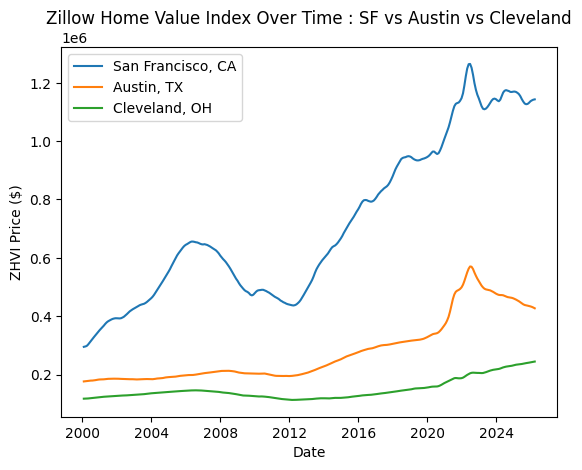

In [5]:
for metro in target_metros:
    metro_data = reshaped_data[reshaped_data['RegionName'] == metro]
    plt.plot(metro_data['Date'], metro_data['ZHVI'], label = metro)
plt.title('Zillow Home Value Index Over Time : SF vs Austin vs Cleveland')
plt.xlabel('Date')
plt.ylabel('ZHVI Price ($)')
plt.legend()
plt.show()

#2. Collection of external variables
Having defined the target variable, housing prices, we proceed to collect explanatory variables (FRED macro series, Census ACS demographics, and mortgage rate data) that affect housing prices for the construction of a nowcasting model.

##(1) FRED macro series
We first utilize the Federal Reserve Economic Data (FRED) API to collect key macroeconomic indicators. The selected FRED macro series include the unemployment rate (labor market condition), the Consumer Price Index (inflation), and personal income as a proxy for housing affordability. Since nowcasting is conducted at a monthly frequency, we standardize all data to a monthly frequency during data collection. We begin by installing the FRED API package.

In [6]:
!pip install fredapi
from fredapi import Fred

Next, we collect data from FRED API and enforce a monthly frequency for all series.

In [7]:
def fetch_fred_series(api_key, series_id):
    fred = Fred(api_key=api_key)
    series = fred.get_series(series_id, frequency='m')
    return series

The three macroeconomic time series are merged into a unified dataset, and rows containing missing values are dropped to ensure that only complete observations are retained.

In [8]:
def compile_macro_data(api_key):
    unrate = fetch_fred_series(api_key, 'UNRATE')
    cpi = fetch_fred_series(api_key, 'CPIAUCSL')
    income = fetch_fred_series(api_key, 'PI')
    macro_df = pd.DataFrame({'Unrate': unrate, 'CPI': cpi, 'Income': income})
    macro_df.index.name = 'Date'
    return macro_df.dropna().reset_index()
my_key = '5c08d8bf72bf6adc502870943972777e'
macro_df = compile_macro_data(my_key)

We standardize the date format in order to merge this dataset with the Zillow data.

In [9]:
macro_df['Date'] = pd.to_datetime(macro_df['Date'])
print(macro_df.head())

        Date  Unrate    CPI  Income
0 1959-01-01     6.0  29.01   391.8
1 1959-02-01     5.9  29.00   393.7
2 1959-03-01     5.6  28.97   396.5
3 1959-04-01     5.2  28.98   399.9
4 1959-05-01     5.1  29.04   402.4


##(2) mortgage rate
When mortgage rates rise, borrowing costs increase, which reduces housing demand and ultimately puts downward pressure on house prices. Therefore, we now collect mortgage rates, a key determinant of housing purchase costs. In this case as well, we collect data at a monthly frequency.

In [10]:
def fetch_mortgage_data(api_key):
    fred = Fred(api_key=api_key)
    mortgage = fred.get_series('MORTGAGE30US', frequency='m')
    mortgage_df = pd.DataFrame({'Mortgage_Rate': mortgage})
    mortgage_df.index.name = 'Date'
    return mortgage_df.dropna().reset_index()
mortgage_df = fetch_mortgage_data(my_key)
mortgage_df['Date'] = pd.to_datetime(mortgage_df['Date'])
print(mortgage_df.head())

        Date  Mortgage_Rate
0 1971-04-01           7.31
1 1971-05-01           7.43
2 1971-06-01           7.53
3 1971-07-01           7.60
4 1971-08-01           7.70


Before collecting additional demographic data, we merge the existing macro_df, mortgage_df, and reshaped Zillow dataset into a single dataset. The merge is performed based on the ‘Date’ column, ensuring that all columns from each dataset are fully retained. Meanwhile, when merging by date, we align the date formats of the FRED and Zillow datasets by setting all dates to the first day of each month.

In [11]:
reshaped_data['Date'] = pd.to_datetime(reshaped_data['Date']).dt.to_period('M').dt.to_timestamp().copy()
fred_data = pd.merge(macro_df, mortgage_df, on='Date', how='inner')
merged_df = pd.merge(reshaped_data, fred_data, on='Date', how='inner')
merged_df.head()

,RegionName,Date,ZHVI,Unrate,CPI,Income,Mortgage_Rate
0,"Austin, TX",2000-01-01,176345.254321,4.0,169.3,8348.0,8.21
1,"Austin, TX",2000-02-01,176925.128914,4.1,170.0,8408.8,8.33
2,"Austin, TX",2000-03-01,177456.082518,4.0,171.0,8468.3,8.24
3,"Austin, TX",2000-04-01,178300.266555,3.8,170.9,8506.8,8.15
4,"Austin, TX",2000-05-01,178937.765779,4.0,171.2,8544.5,8.52


##(3) Census ACS demographics
While the previously collected FRED macroeconomic data captures overall national housing market conditions, we now collect American Community Survey (ACS) demographic data to better represent local housing demand and purchasing power. This step is intended to incorporate regional differences in market dynamics into the model. Using the ACS from the U.S. Census Bureau, we collect median household income, educational attainment (share of individuals with a bachelor’s degree or higher), and total population for each metropolitan area. We use Census data extracted from FRED API, and convert these annual indicators into monthly series by assigning the same value to all months within each year to construct a complete monthly time series dataset. We begin by specifying the FRED series IDs used for each region.(We use Cuyahoga County data as a proxy for the Cleveland metropolitan area.)

In [12]:
fred = Fred(api_key='5c08d8bf72bf6adc502870943972777e')
census_ID = {
    "San Francisco, CA": {"Income":"MHICA06075A052NCEN","Education":"GCT1502CA","Population": "CAPOP"},
    "Austin, TX": {"Income":"MHITX48015A052NCEN","Education":"GCT1502TX","Population":"TXPOP"},
    "Cleveland, OH": {"Income":"MHIOH39035A052NCEN","Education":"GCT1502OH","Population":"OHPOP"}
}

Next, we initialize an empty list to store multiple Census data frames.

In [13]:
all_census = []

We collect data for each region defined in the dictionary. The data are retrieved via the FRED API and then converted into data frames with appropriately assigned column names. We then aggregate and merge the data by year, and append the resulting metro-level dataset to the previously initialized empty list.

In [14]:
for metro, IDs in census_ID.items():
    medinc = fred.get_series(IDs["Income"]).to_frame(name='MedianIncome')
    edu = fred.get_series(IDs["Education"]).to_frame(name='EduAttainment')
    pop = fred.get_series(IDs["Population"]).to_frame(name='TotalPopulation')
    metro_census = pd.concat([medinc, edu, pop], axis=1).reset_index()
    metro_census.rename(columns={'index':'Year'}, inplace=True)
    metro_census['Year'] = metro_census['Year'].dt.year
    metro_census = metro_census.groupby('Year').mean().reset_index()
    metro_census['RegionName'] = metro
    all_census.append(metro_census)

We combine the datasets for the three metros stored in the list into a single dataset.

In [15]:
census_data = pd.concat(all_census)

##(4) Construction of the Unified Analytical Dataset
Merge the target variable, Zillow ZHVI data, and external explanatory variables—FRED macroeconomic indicators, mortgage rates, and Census ACS demographic data—into a single dataframe based on 'Date' and 'RegionName'. This is to secure a unified dataset for analysis by aligning all independent and dependent variables at the same unit of observation (Month-Metro) for time-series analysis and machine learning model training. Since the merged_data is at a monthly frequency, we first extract the year to ensure consistency in the merging criteria.

In [16]:
merged_df['Year'] = merged_df['Date'].dt.year
final_data = pd.merge(merged_df, census_data, on=['RegionName','Year'], how='left')

Since Census data are available only at an annual frequency and are released with a time lag, we impute missing values by assuming that demographic characteristics remain stable in the short term. This approach preserves the continuity of the time series. Any remaining missing values are strictly dropped to ensure data integrity.

In [28]:
for col in ['MedianIncome','EduAttainment','TotalPopulation']:
    final_data[col] = final_data.groupby('RegionName')[col].ffill()
final_dataset = final_data.dropna().reset_index(drop=True)
final_dataset = final_dataset.drop(columns='Year')
final_dataset.head()

,RegionName,Date,ZHVI,Unrate,CPI,Income,Mortgage_Rate,MedianIncome,EduAttainment,TotalPopulation
0,"Austin, TX",2006-01-01,197823.426792,4.7,199.3,11038.6,6.15,46603.0,24.7,23359.58
1,"Austin, TX",2006-02-01,198140.956992,4.8,199.4,11102.6,6.25,46603.0,24.7,23359.58
2,"Austin, TX",2006-03-01,198154.990018,4.7,199.7,11171.8,6.32,46603.0,24.7,23359.58
3,"Austin, TX",2006-04-01,198242.907561,4.7,200.7,11229.5,6.51,46603.0,24.7,23359.58
4,"Austin, TX",2006-05-01,198447.835467,4.6,201.3,11251.1,6.60,46603.0,24.7,23359.58


Meanwhile, the data fed into our final model consists of period-over-period variations. To achieve stationarity, we applied the monthly percentage change to level variables (such as housing prices, income, and population) and the first difference (percentage point change) to variables already in percentage units (such as mortgage rates and education index). By applying these tailored transformations, we designed the model to accurately capture the short-term shocks that relative fluctuations impose on the housing market without distortion.

In [30]:
final_dataset = final_dataset.sort_values(by=['RegionName', 'Date'])
level_cols = ['ZHVI', 'CPI', 'Income', 'MedianIncome', 'TotalPopulation']
for col in level_cols:
    final_dataset[f'{col}_pct'] = final_dataset.groupby('RegionName')[col].pct_change() * 100
rate_cols = ['Unrate', 'Mortgage_Rate', 'EduAttainment']
for col in rate_cols:
    final_dataset[f'{col}_diff'] = final_dataset.groupby('RegionName')[col].diff()
final_df= final_dataset.dropna().reset_index(drop=True).copy()
final_df.head()

,RegionName,Date,ZHVI,Unrate,CPI,Income,Mortgage_Rate,MedianIncome,EduAttainment,TotalPopulation,ZHVI_pct,CPI_pct,Income_pct,MedianIncome_pct,TotalPopulation_pct,Unrate_diff,Mortgage_Rate_diff,EduAttainment_diff
0,"Austin, TX",2006-02-01,198140.956992,4.8,199.4,11102.6,6.25,46603.0,24.7,23359.58,0.160512,0.050176,0.579784,0.0,0.0,0.1,0.10,0.0
1,"Austin, TX",2006-03-01,198154.990018,4.7,199.7,11171.8,6.32,46603.0,24.7,23359.58,0.007082,0.150451,0.623277,0.0,0.0,-0.1,0.07,0.0
2,"Austin, TX",2006-04-01,198242.907561,4.7,200.7,11229.5,6.51,46603.0,24.7,23359.58,0.044368,0.500751,0.516479,0.0,0.0,0.0,0.19,0.0
3,"Austin, TX",2006-05-01,198447.835467,4.6,201.3,11251.1,6.60,46603.0,24.7,23359.58,0.103372,0.298954,0.192351,0.0,0.0,-0.1,0.09,0.0
4,"Austin, TX",2006-06-01,198993.558427,4.6,201.8,11292.8,6.68,46603.0,24.7,23359.58,0.274996,0.248385,0.370630,0.0,0.0,0.0,0.08,0.0


#3. Exploratory Data Analysis
##(1) Correlation
Prior to model estimation, we analyze the relationships between the collected explanatory variables and housing price changes. This step helps **identify the most influential predictors and prevents multicollinearity**. As high correlations among regressors can result in unstable coefficient estimates, we conduct this diagnostic analysis in advance.

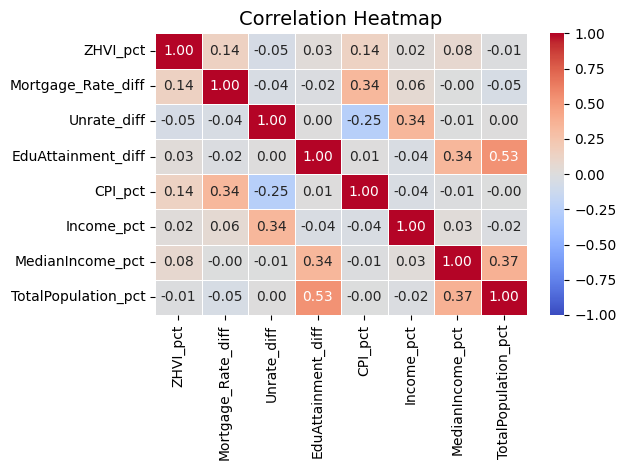

In [19]:
target_cols = ['ZHVI_pct','Mortgage_Rate_diff','Unrate_diff','EduAttainment_diff',
               'CPI_pct','Income_pct','MedianIncome_pct','TotalPopulation_pct']
numeric_data = final_df[target_cols]
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

Since the correlation coefficients between the independent variables are all within an appropriate range, it indicates that each variable in the current dataset maintains independent and distinct information.

#4. Baseline Modeling
Now, we will perform OLS multiple regression analysis for each metro area to compare which variables are significant by region. We define the list of independent variables and execute the code to run the OLS model iteratively for each of the three metros.

In [20]:
X_cols = ['Mortgage_Rate_diff', 'Unrate_diff', 'EduAttainment_diff',
          'CPI_pct', 'Income_pct', 'MedianIncome_pct', 'TotalPopulation_pct']

for metro in final_df['RegionName'].unique():
    print(f"\n\n{'-'*47}")
    print(f"OLS Regression Results for: {metro.upper()}")
    print(f"{'-'*47}")
    metro_data = final_df[final_df['RegionName'] == metro]
    X = sm.add_constant(metro_data[X_cols])
    y = metro_data['ZHVI_pct']
    print(sm.OLS(y, X).fit().summary())



-----------------------------------------------
OLS Regression Results for: AUSTIN, TX
-----------------------------------------------
                            OLS Regression Results                            
Dep. Variable:               ZHVI_pct   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.627
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.129
Time:                        09:28:34   Log-Likelihood:                -317.00
No. Observations:                 241   AIC:                             650.0
Df Residuals:                     233   BIC:                             677.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.0

To compare the regression results across multiple metros at a glance, we generate a coefficient comparison chart. This allows for an intuitive understanding of which variables exert the greatest influence in each specific metro.

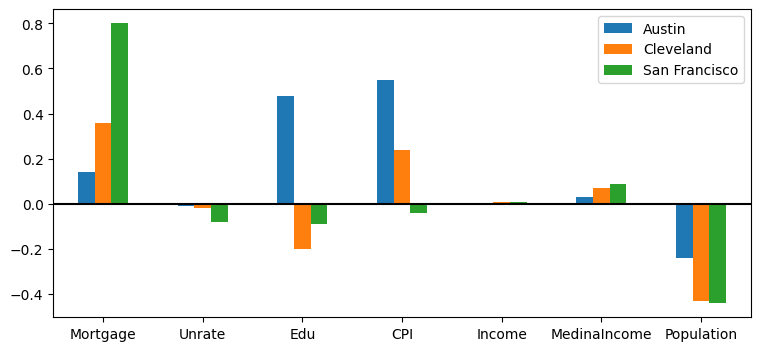

In [21]:
coef = pd.DataFrame({
    'Austin': [0.14, -0.01, 0.48, 0.55, -0.00, 0.03, -0.24],
    'Cleveland': [0.36, -0.02, -0.20, 0.24, 0.01, 0.07, -0.43],
    'San Francisco': [0.80, -0.08, -0.09, -0.04, 0.01, 0.09, -0.44]
}, index=['Mortgage','Unrate','Edu','CPI','Income','MedinaIncome','Population'])
coef.plot(kind='bar', figsize=(9, 4), rot=0)
plt.axhline(0, color='black')
plt.show()

##Interpretation
Comparing the significant variables for each metro area based on the regression results, the findings are as follows. First, looking at the model's explanatory power, the R-squared values range between 4% and 8% for all three regions. However, since we are predicting subtle monthly percentage changes rather than the absolute price level, such low values are to be expected. Our objective is not perfect prediction, but rather identifying the directionality of variables that exert significant impacts; therefore, we focus our analysis on this aspect.

Key variables driving housing prices can be identified by looking for those with a p-value (P>|t|) of less than 0.05.

**Austin**: The most significant variable is CPI_pct (p-value=0.009). This suggests that Austin’s housing market is more sensitive to the overall inflation rate than to other factors.

**Cleveland**: Both CPI_pct (p-value=0.036) and Mortgage_Rate_diff (p-value=0.046) appear as significant variables. This indicates a market where both pillars of the macroeconomy—inflation and mortgage rates—exert immediate influence on housing prices.

**San Francisco**: The analysis highlights MedianIncome_pct (p-value=0.023) and Mortgage_Rate_diff (p-value=0.015) as critical factors. Notably, San Francisco is the only metro where local median income significantly affects the market. This suggests that in a high-priced housing market, both borrowing conditions and the actual income levels of households play a vital role. Furthermore, San Francisco shows the highest sensitivity to mortgage rate changes, which aligns with the economic theory that households in more expensive areas respond more sharply to rate fluctuations.

On the other hand, for Cleveland and San Francisco, the coefficient for Mortgage_Rate_diff is positive. While rising interest rates typically lower housing prices, the positive coefficient in this regression can be explained as follows: in monthly data, central banks often raise interest rates to curb overheating during economic booms when housing prices are rising. This creates an endogeneity issue where price increases and rate hikes appear to occur simultaneously in the short term. To overcome these limitations of the traditional OLS baseline model, further investigation using machine learning models is necessary to capture non-linear relationships.

#5. ML: Gradient Boosting (XGBoost)
Through the previous OLS baseline model analysis, we identified the key variables driving housing prices in each metro and their structural relationships. However, since OLS assumes simple linear relationships between variables, it has limitations in reflecting the complex and non-linear shocks inherent in real-world housing markets. True nowcasting requires more than an interpretation of the past; it demands accurate predictions for new data. Therefore, to achieve high-accuracy nowcasting, we introduce XGBoost, a powerful machine learning algorithm.

In [22]:
!pip install xgboost

We begin by arranging the results for the three metros side-by-side horizontally to allow for easier comparative analysis. After filtering the data for the target metro, we configure and train the XGBoost model. Since our target variable is numerical, we employ the XGBoost Regressor. To prevent overfitting, we limit the tree depth (max_depth) to 3 and split the data into training and testing sets. Reflecting the nature of 'nowcasting' as a time-series task, we do not shuffle the data; instead, we train on the first 80% of the timeline to predict housing prices for the most recent 20%

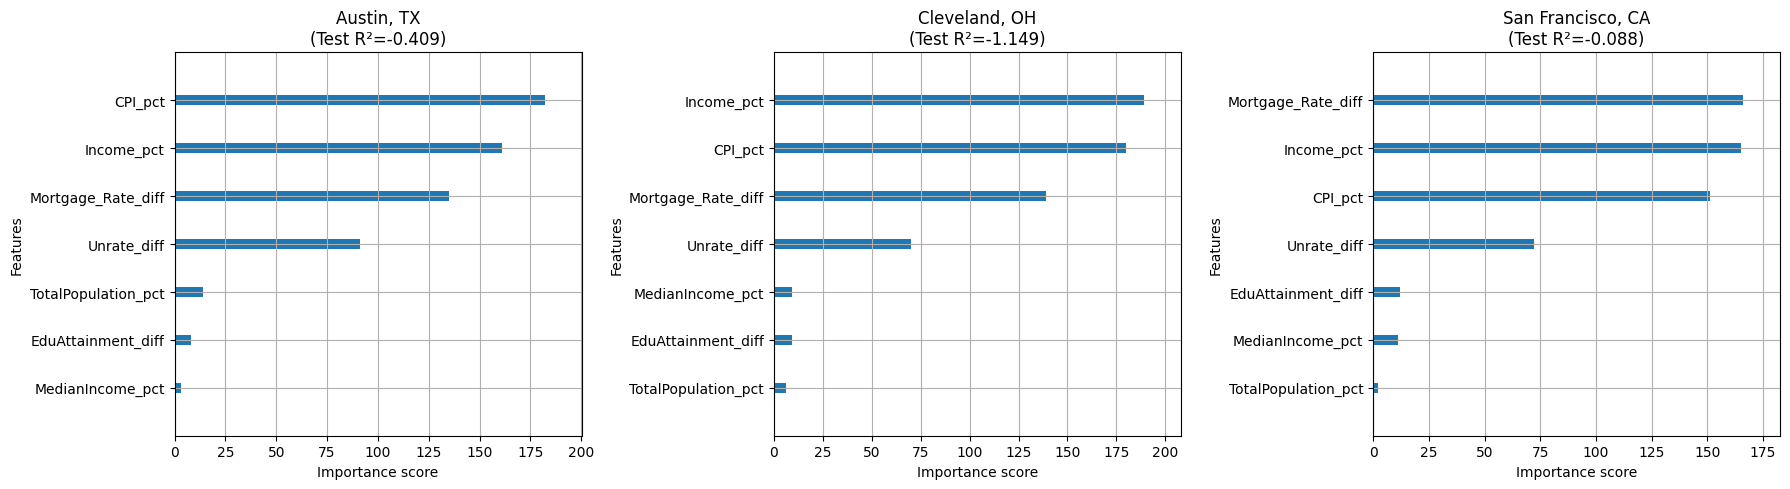

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metro in enumerate(final_df['RegionName'].unique()):
    df = final_df[final_df['RegionName'] == metro]
    X, y = df[X_cols], df['ZHVI_pct']
    X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = XGBRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    plot_importance(model, ax=axes[i], show_values=False, title=f"{metro}\n(Test R²={test_r2:.3f})")
plt.tight_layout()
plt.show()

The out-of-sample test results, which predict the future using past data, yielded negative $R^2$ values across all regions. This indicates that the model's performance was worse than a simple prediction based on the mean. However, rather than viewing this as a failure of the model, it should be interpreted as evidence of a structural shift in the housing market where past macroeconomic patterns no longer apply. Unlike the training period, the test period was characterized by unprecedented events: the COVID-19 pandemic, soaring inflation, the Fed’s zero-interest-rate policy, and subsequent rapid rate hikes. As a new era emerged—fundamentally different from the past—the machine learning model, which had memorized historical patterns, struggled to predict the recent real estate market. This suggests an inherent limitation: simple macroeconomic indicators alone are insufficient for the monthly nowcasting of extraordinary market shocks, such as the pandemic and aggressive monetary tightening.

While OLS analysis excels at identifying the average directionality between variables, it is limited in capturing the complex, non-linearities of the real-world economy. In contrast, XGBoost’s feature importance measures the contribution of information rather than direction, revealing how heavily the model relies on specific variables to reach its conclusions. This allows for a more multi-dimensional analysis of the regional characteristics and the specific economic shocks to which each of the three metro housing markets is most vulnerable.

According to the feature importance analysis, demographic indicators such as population, local median income, and education levels remained at the bottom. This stems from the fact that this project aims for nowcasting monthly fluctuations rather than predicting long-term price levels. These micro-indicators do not provide enough variance to explain the short-term momentum of a rapidly changing monthly housing market. Conversely, real-time macroeconomic indicators immediately reflect changes in market liquidity and economic sentiment, acting as the primary drivers governing the short-term housing market.
San Francisco: Mortgage rates emerged as the key predictive variable for price fluctuations.
Austin: The Consumer Price Index (CPI) was identified as the most critical factor.
Cleveland: Interestingly, the model relied most heavily on individual income.
If mortgage rates in San Francisco represent monetary policy and Austin’s CPI represents macro-momentum, then Cleveland’s income represents the fundamentals of the real economy. It can be inferred that Cleveland maintains the essence of a traditional housing market, where prices move only when supported by the actual purchasing power of end-users, rather than by external financial shocks.

In conclusion, this machine learning feature importance analysis proves that the U.S. housing market does not operate under a single logic. While macroeconomic indicators are essential for short-term nowcasting, the key triggers—whether they be monetary policy, inflation, or real income—are distinctly differentiated based on regional characteristics (High-cost asset markets vs. Momentum-driven growth markets vs. Traditional fundamental markets). This suggests that customized nowcasting models that reflect regional structural characteristics are essential, rather than a one-size-fits-all national housing policy.
